# Mohamed Ehab — Pang et al. (2025)

**Paper basis:** Pang et al. (2025) compared LR, DT, RF, SVM, KNN, GBM, and MARS on a CDC-derived diabetes dataset and used Shapley values for explainability.

**This notebook implements:**
- Main model: Gradient Boosting
- Second started model: Logistic Regression
- XAI: SHAP, LIME, Permutation Feature Importance, PDP

In [ ]:


%pip -q install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn shap lime

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if not hasattr(np, "bool"):
    np.bool = np.bool_
if not hasattr(np, "int"):
    np.int = int

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print("Drive mount skipped or not running in Colab:", e)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import shap
from lime.lime_tabular import LimeTabularExplainer

sns.set(style="whitegrid")
RANDOM_STATE = 42

DATA_DIR = "/content/drive/MyDrive/BRFSS2015_processed"
OUTPUT_DIR = os.path.join(DATA_DIR, "model_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_path = os.path.join(DATA_DIR, "train.csv")
test_path = os.path.join(DATA_DIR, "test.csv")


train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df = train_df.loc[:, ~train_df.columns.str.contains("^Unnamed")]
test_df = test_df.loc[:, ~test_df.columns.str.contains("^Unnamed")]

TARGET = "Diabetes"
if TARGET not in train_df.columns:
    raise ValueError(f"Target column '{TARGET}' not found. Available columns: {train_df.columns.tolist()}")

for c in train_df.columns:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce")
for c in test_df.columns:
    test_df[c] = pd.to_numeric(test_df[c], errors="coerce")

medians = train_df.median(numeric_only=True)
train_df = train_df.fillna(medians)
test_df = test_df.fillna(medians)

X_train_full = train_df.drop(columns=[TARGET])
y_train_full = train_df[TARGET].astype(int)

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET].astype(int)

X_test = X_test[X_train_full.columns]

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

feature_cols = list(X_train.columns)
classes = sorted(y_train_full.unique().tolist())

if classes == [0, 1, 2]:
    CLASS_NAMES = ["No Diabetes", "Prediabetes", "Diabetes"]
else:
    CLASS_NAMES = [f"Class {c}" for c in classes]

print("Data loaded successfully")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("Classes:", classes)
display(train_df.head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Mounted at /content/drive
Data loaded successfully
Train: (170046, 20)
Validation: (30009, 20)
Test: (50014, 20)
Classes: [0, 1, 2]


,GenHlth,HighBP,GenHlth_x_DiffWalk,BMI_x_Age,CV_burden_weighted,HighChol,DiffWalk,Sex,BMI_class,SES_risk_score,...,PhysActivity,HeartDiseaseorAttack,HvyAlcoholConsump,MetS_score,BMI,FINDRISC_score,PhysHlth,TimeSinceCheckup,Age,Diabetes
0,3,0,-0.433062,0.193680,-0.470845,0,0,0,1,-0.071259,...,1,0,1,-2.058808,-1.423732,-0.913473,-0.491136,1.0,13,0
1,4,0,2.385799,-0.628963,0.592255,0,1,1,1,-0.410719,...,0,0,0,-2.002222,-0.715396,-0.419763,2.924341,4.0,7,0
2,1,1,-0.433062,0.116589,-0.470845,0,0,1,2,-1.089639,...,1,0,1,-0.300457,-0.278337,0.073947,-0.491136,1.0,9,0
3,3,0,-0.433062,1.469741,-0.470845,1,0,1,5,-0.410719,...,0,0,1,0.991543,2.735860,1.061367,-0.263437,2.0,8,0
4,4,0,2.385799,0.711002,0.592255,0,1,1,2,0.947122,...,0,0,1,-1.338971,0.203934,0.567657,2.924341,1.0,10,2


##Helpers

In [ ]:
def evaluate_model(y_true, y_prob):
    y_pred = np.asarray(y_prob).argmax(axis=1)

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        out["roc_auc_ovr_weighted"] = roc_auc_score(
            y_true, y_prob, multi_class="ovr", average="weighted"
        )
    except Exception as e:
        out["roc_auc_ovr_weighted"] = np.nan
        print("ROC-AUC could not be computed:", e)

    return out


def metrics_frame(model_name, split_name, y_true, y_prob):
    row = {"model": model_name, "split": split_name}
    row.update(evaluate_model(y_true, y_prob))
    return pd.DataFrame([row])


def report_and_confusion(model_name, y_true, y_prob, save=True):
    y_pred = np.asarray(y_prob).argmax(axis=1)

    print(f"\nClassification report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(cmap="Blues", xticks_rotation=20)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()

    if save:
        path = os.path.join(OUTPUT_DIR, f"{model_name}_confusion_matrix.png")
        plt.savefig(path, dpi=200, bbox_inches="tight")
        print("Saved confusion matrix:", path)

    plt.show()


def get_class_index(estimator, target_label=2):
    probs = estimator.predict_proba(X_test.iloc[:2])
    est_classes = getattr(estimator, "classes_", np.arange(probs.shape[1]))

    if target_label in est_classes:
        return list(est_classes).index(target_label)

    return probs.shape[1] - 1


def predict_proba_as_df(estimator, data, columns):
    df = pd.DataFrame(data, columns=columns)
    return estimator.predict_proba(df)


def predict_class_probability(estimator, data, columns, class_index):
    return predict_proba_as_df(estimator, data, columns)[:, class_index]


def save_metrics_csv(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print("Saved metrics:", path)


def run_lime(estimator, model_name, instance_index=0, num_features=10):
    explainer = LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=feature_cols,
        class_names=CLASS_NAMES,
        discretize_continuous=True,
        mode="classification",
        random_state=RANDOM_STATE
    )

    exp = explainer.explain_instance(
        X_test.iloc[instance_index].values,
        lambda x: predict_proba_as_df(estimator, x, feature_cols),
        num_features=num_features,
        top_labels=len(CLASS_NAMES)
    )

    print("True label:", y_test.iloc[instance_index])
    print("Predicted probabilities:", estimator.predict_proba(X_test.iloc[[instance_index]])[0])
    exp.show_in_notebook(show_table=True)
    return exp


def run_kernel_shap_for_class(estimator, model_name, target_label=2, background_size=60, explain_size=20):
    class_index = get_class_index(estimator, target_label=target_label)

    background = shap.sample(X_train, min(background_size, len(X_train)), random_state=RANDOM_STATE)
    explain_X = shap.sample(X_test, min(explain_size, len(X_test)), random_state=RANDOM_STATE)

    f = lambda data: predict_class_probability(estimator, data, feature_cols, class_index)

    explainer = shap.KernelExplainer(f, background)
    shap_values = explainer.shap_values(explain_X, nsamples=100)

    shap.summary_plot(shap_values, explain_X, feature_names=feature_cols, show=True)
    return shap_values, explain_X


def run_pfi(estimator, model_name):
    pfi = permutation_importance(
        estimator,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="roc_auc_ovr_weighted"
    )

    pfi_df = pd.DataFrame({
        "feature": feature_cols,
        "importance_mean": pfi.importances_mean,
        "importance_std": pfi.importances_std
    }).sort_values("importance_mean", ascending=False)

    display(pfi_df.head(15))

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=pfi_df.head(12),
        x="importance_mean",
        y="feature",
        orient="h"
    )
    plt.title(f"{model_name} - Permutation Feature Importance")
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, f"{model_name}_pfi.png")
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved PFI figure:", path)
    plt.show()

    pfi_df.to_csv(os.path.join(OUTPUT_DIR, f"{model_name}_pfi.csv"), index=False)
    return pfi_df


def run_pdp(estimator, model_name, target_label=2):
    wanted = ["BMI", "Age", "GenHlth", "HighBP"]
    pdp_features = [c for c in wanted if c in X_test.columns]

    if len(pdp_features) == 0:
        pdp_features = feature_cols[:4]

    try:
        PartialDependenceDisplay.from_estimator(
            estimator,
            X_test,
            pdp_features,
            target=target_label
        )
        plt.suptitle(f"{model_name} - PDP for Class {target_label}", y=1.02)
        plt.tight_layout()
        path = os.path.join(OUTPUT_DIR, f"{model_name}_pdp.png")
        plt.savefig(path, dpi=200, bbox_inches="tight")
        print("Saved PDP figure:", path)
        plt.show()
    except Exception as e:
        print("PDP failed:", e)

## Main Model: Gradient Boosting

,model,split,accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_weighted
0,GBM_Pang,validation,0.839881,0.790480,0.839881,0.800165,0.809055
1,GBM_Pang,test,0.839965,0.790011,0.839965,0.799446,0.809680


Saved metrics: /content/drive/MyDrive/BRFSS2015_processed/model_outputs/GBM_Pang_metrics.csv

Classification report for GBM_Pang:
              precision    recall  f1-score   support

 No Diabetes     0.8548    0.9758    0.9113     41641
 Prediabetes     0.0000    0.0000    0.0000      1319
    Diabetes     0.5553    0.1949    0.2886      7054

    accuracy                         0.8400     50014
   macro avg     0.4700    0.3903    0.4000     50014
weighted avg     0.7900    0.8400    0.7994     50014

Saved confusion matrix: /content/drive/MyDrive/BRFSS2015_processed/model_outputs/GBM_Pang_confusion_matrix.png


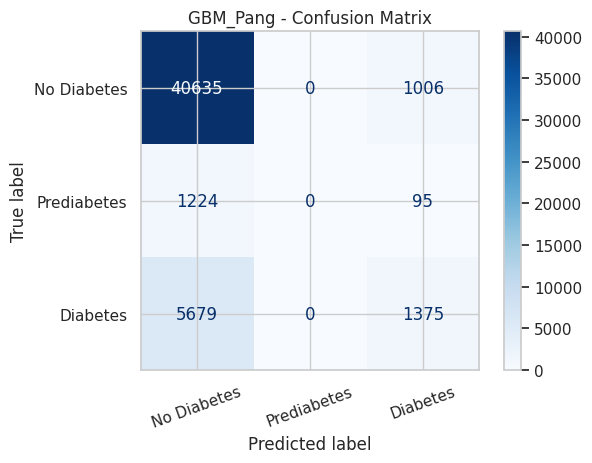

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

gbm_model = Pipeline([
    ("scaler", MinMaxScaler(feature_range=(-1, 1))),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

gbm_model.fit(X_train, y_train)

gbm_val_prob = gbm_model.predict_proba(X_val)
gbm_test_prob = gbm_model.predict_proba(X_test)

gbm_metrics = pd.concat([
    metrics_frame("GBM_Pang", "validation", y_val, gbm_val_prob),
    metrics_frame("GBM_Pang", "test", y_test, gbm_test_prob)
], ignore_index=True)

display(gbm_metrics)
save_metrics_csv(gbm_metrics, "GBM_Pang_metrics.csv")
report_and_confusion("GBM_Pang", y_test, gbm_test_prob)

## Second Model : Logistic Regression

,model,split,accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_weighted
0,LogReg_Pang,validation,0.603119,0.835859,0.603119,0.679414,0.798695
1,LogReg_Pang,test,0.605011,0.837133,0.605011,0.680796,0.797963


Saved metrics: /content/drive/MyDrive/BRFSS2015_processed/model_outputs/LogReg_Pang_metrics.csv

Classification report for LogReg_Pang:
              precision    recall  f1-score   support

 No Diabetes     0.9448    0.6056    0.7381     41641
 Prediabetes     0.0426    0.3283    0.0755      1319
    Diabetes     0.3501    0.6535    0.4559      7054

    accuracy                         0.6050     50014
   macro avg     0.4458    0.5291    0.4232     50014
weighted avg     0.8371    0.6050    0.6808     50014

Saved confusion matrix: /content/drive/MyDrive/BRFSS2015_processed/model_outputs/LogReg_Pang_confusion_matrix.png


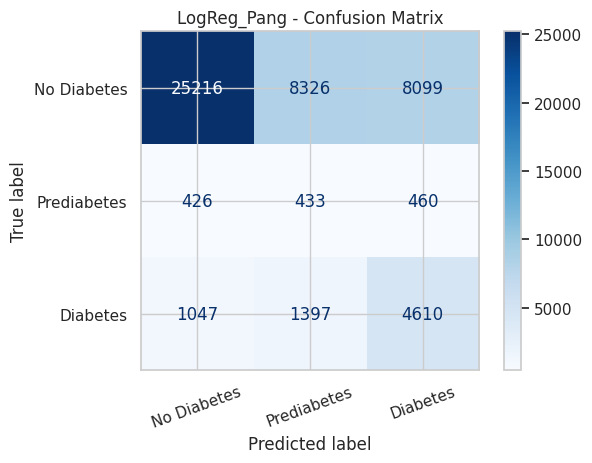

In [ ]:
logreg_model = Pipeline([
    ("scaler", MinMaxScaler(feature_range=(-1, 1))),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        multi_class="multinomial",
        random_state=RANDOM_STATE
    ))
])

logreg_model.fit(X_train, y_train)

lr_val_prob = logreg_model.predict_proba(X_val)
lr_test_prob = logreg_model.predict_proba(X_test)

lr_metrics = pd.concat([
    metrics_frame("LogReg_Pang", "validation", y_val, lr_val_prob),
    metrics_frame("LogReg_Pang", "test", y_test, lr_test_prob)
], ignore_index=True)

display(lr_metrics)
save_metrics_csv(lr_metrics, "LogReg_Pang_metrics.csv")
report_and_confusion("LogReg_Pang", y_test, lr_test_prob)

## Explainability for Main Model

,feature,importance_mean,importance_std
0,GenHlth,0.047869,0.001325
1,HighBP,0.029019,0.001087
3,BMI_x_Age,0.028889,0.000539
15,BMI,0.006707,0.000300
18,TimeSinceCheckup,0.005659,0.000231
14,MetS_score,0.005562,0.000203
7,Sex,0.005306,0.000409
5,HighChol,0.004830,0.000198
4,CV_burden_weighted,0.003207,0.000151
13,HvyAlcoholConsump,0.002138,0.000155


Saved PFI figure: /content/drive/MyDrive/BRFSS2015_processed/model_outputs/GBM_Pang_pfi.png


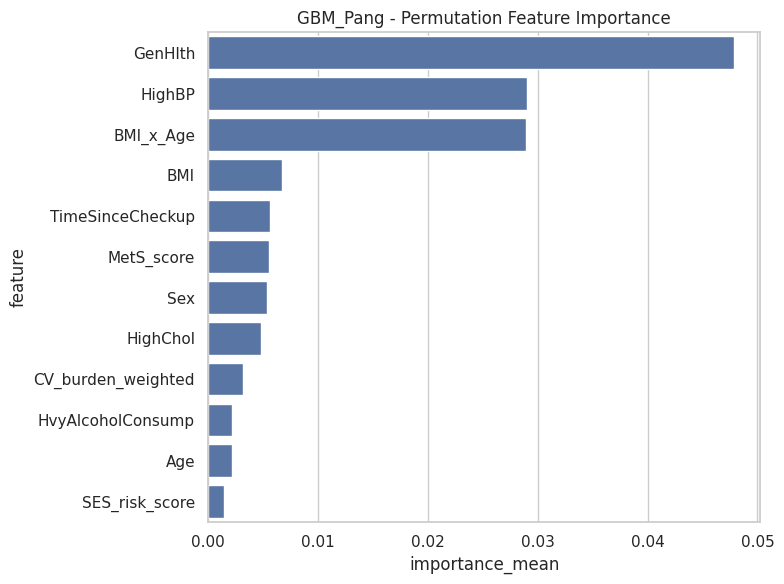

Saved PDP figure: /content/drive/MyDrive/BRFSS2015_processed/model_outputs/GBM_Pang_pdp.png


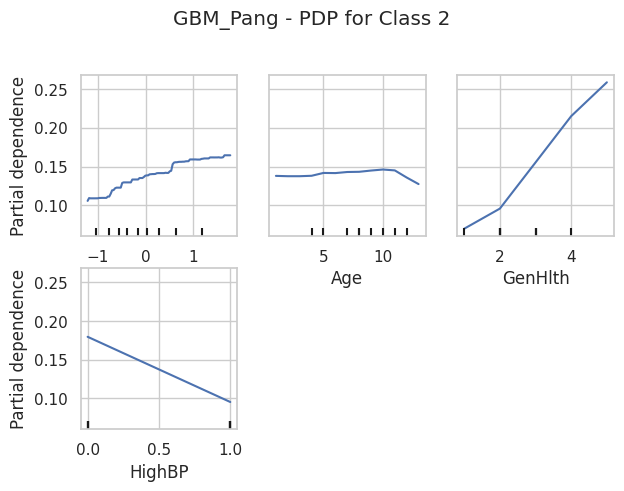

In [ ]:
pfi_df = run_pfi(gbm_model, "GBM_Pang")
run_pdp(gbm_model, "GBM_Pang", target_label=2)

## SHAP Explanation

  0%|          | 0/20 [00:00<?, ?it/s]

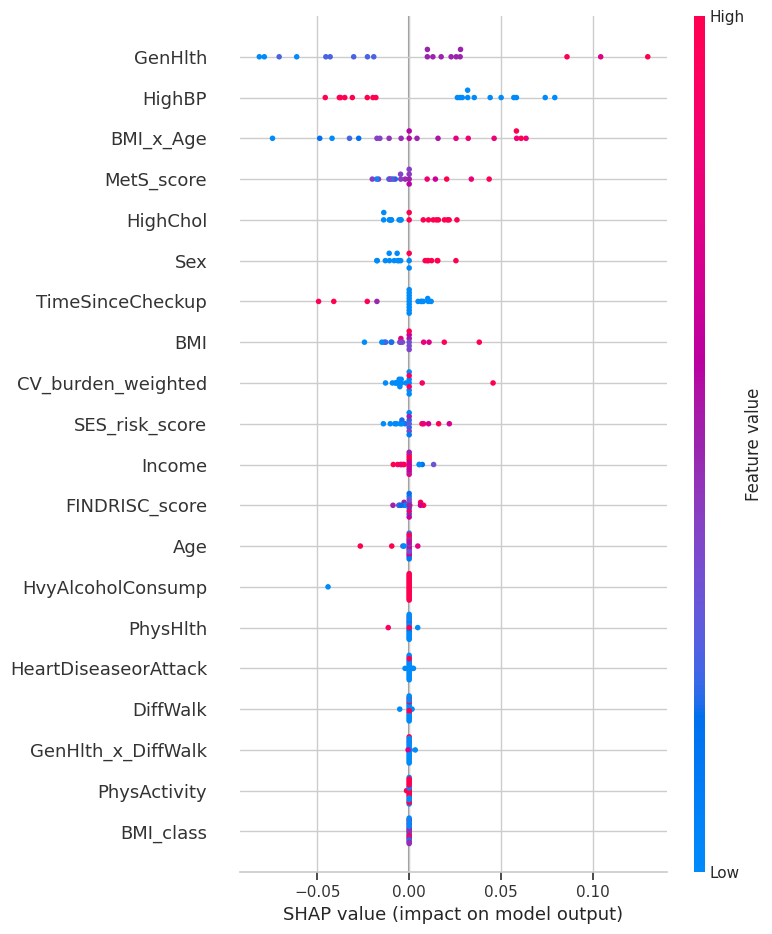

In [ ]:
shap_values, shap_X = run_kernel_shap_for_class(
    gbm_model,
    "GBM_Pang",
    target_label=2,
    background_size=60,
    explain_size=20
)

## LIME Explanation

In [ ]:
lime_exp = run_lime(gbm_model, "GBM_Pang", instance_index=0, num_features=10)

True label: 0
Predicted probabilities: [0.9047645 0.0373171 0.0579184]
